In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Flagging Vendor Invoices for Manual Review

**Objective:** Predict whether a vendor invoice should be flagged for manual approval based on abnormal cost, freight, or delivery patterns, in order to reduce financial risk, improve operational efficiency, and prioritize human review where it adds the most value.
* Manual invoice review is time-consuming and does not scale with transaction volume.
* Abnormal freight charges, pricing deviations, or delivery delays often indicate errors, disputes, or compliance risks.
* An automated flagging system enables finance teams to focus attention on high-risk invoices while allowing low-risk invoices to be processed automatically.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
conn = sqlite3.connect('/content/drive/MyDrive/inventory.db')

In [4]:
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)
print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [9]:
display(pd.read_sql_query("SELECT * FROM purchases LIMIT 5", conn))

,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


In [14]:
purchase_agg_df = pd.read_sql_query(
    """
    SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS Total_Brands,
    SUM(p.Quantity) AS Total_Item_Quantity,
    SUM(p.Dollars) AS Total_Item_Dollars,
    AVG(JULIANDAY(p.ReceivingDate) - JULIANDAY(p.PODate)) AS Avg_Reciving_Delay
    FROM purchases AS p
    GROUP BY p.PONumber
    """, conn)

In [16]:
pd.read_sql_query(
    """
    SELECT
    vi.Quantity AS Invoice_Quantity,
    vi.Dollars AS Invoice_Dollars,
    vi.Freight AS Freight_Cost,
    (JULIANDAY(vi.InvoiceDate)- JULIANDAY(vi.PODate)) AS Days_Po_To_Invoice,
    (JULIANDAY(vi.PayDate) - JULIANDAY(vi.InvoiceDate)) AS Days_To_Pay
    FROM vendor_invoice AS vi
    """, conn)

,Invoice_Quantity,Invoice_Dollars,Freight_Cost,Days_Po_To_Invoice,Days_To_Pay
0,6,214.26,3.47,14.0,43.0
1,15,140.55,8.57,16.0,45.0
2,5,106.60,4.61,16.0,38.0
3,10100,137483.78,2935.20,23.0,24.0
4,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...
5538,90,1563.00,8.60,16.0,35.0
5539,4617,37300.48,186.50,18.0,39.0
5540,9848,202815.78,932.95,11.0,33.0
5541,24747,149007.56,819.54,14.0,36.0


In [27]:
df = pd.read_sql_query(
    """
    WITH PData AS(
    SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS Total_Brands,
    SUM(p.Quantity) AS Total_Item_Quantity,
    SUM(p.Dollars) AS Total_Item_Dollars,
    AVG(JULIANDAY(p.ReceivingDate) - JULIANDAY(p.PODate)) AS Avg_Reciving_Delay
    FROM purchases AS p
    GROUP BY p.PONumber
    )

    SELECT
    vi.PONumber,
    vi.Quantity AS Invoice_Quantity,
    vi.Dollars AS Invoice_Dollars,
    vi.Freight AS Freight_Cost,
    (JULIANDAY(vi.InvoiceDate)- JULIANDAY(vi.PODate)) AS Days_Po_To_Invoice,
    (JULIANDAY(vi.PayDate) - JULIANDAY(vi.InvoiceDate)) AS Days_To_Pay,
    pd.Total_Brands,
    pd.Total_Item_Quantity,
    pd.Total_Item_Dollars,
    pd.Avg_Reciving_Delay
    FROM vendor_invoice AS vi
    LEFT JOIN PData AS pd
    ON vi.PONumber = pd.PONumber
    """, conn)

In [28]:
print(df.isnull().sum(),"\n")
print(df.dtypes)

PONumber               0
Invoice_Quantity       0
Invoice_Dollars        0
Freight_Cost           0
Days_Po_To_Invoice     0
Days_To_Pay            0
Total_Brands           0
Total_Item_Quantity    0
Total_Item_Dollars     0
Avg_Reciving_Delay     0
dtype: int64 

PONumber                 int64
Invoice_Quantity         int64
Invoice_Dollars        float64
Freight_Cost           float64
Days_Po_To_Invoice     float64
Days_To_Pay            float64
Total_Brands             int64
Total_Item_Quantity      int64
Total_Item_Dollars     float64
Avg_Reciving_Delay     float64
dtype: object


#### Creating label for trainig model

In [29]:
def create_invoice_risk_label(row):
  if(abs(row["Invoice_Dollars"] - row["Total_Item_Dollars"]) > 5):
    return 1 # if amount in invoice and in purchases order is different then "Manual Review"

  if row["Avg_Reciving_Delay"] > 10:
    return 1 # if averaging delay is more than 10 days then "Manual Review"

  return 0
df["Flag_Invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["Flag_Invoice"].value_counts()

,count
Flag_Invoice,
0,3693
1,1850


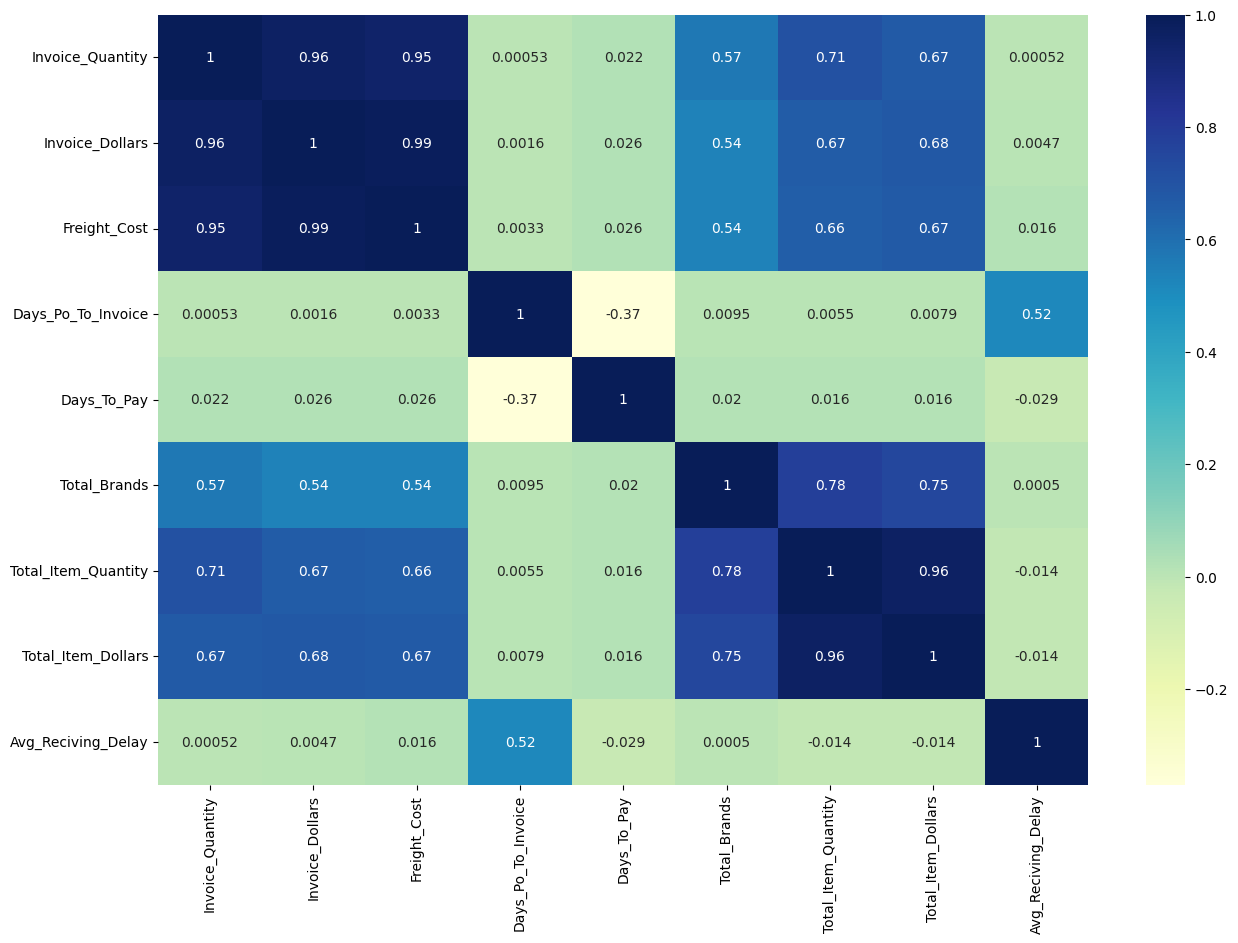

In [31]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.iloc[:,1:-1].corr(), annot=True, cmap="YlGnBu")
plt.show()

In [43]:
flagged = df[df["Flag_Invoice"] == 1]
normal = df[df["Flag_Invoice"] == 0]

#### T Testing


In [44]:
significant_features = []
non_significant_features = []
results = []

In [52]:
metrics = [
'Invoice_Quantity', 'Invoice_Dollars', 'Freight_Cost',
'Days_Po_To_Invoice', 'Days_To_Pay', 'Total_Brands',
'Total_Item_Quantity', 'Total_Item_Dollars','Avg_Reciving_Delay']

In [53]:
from scipy.stats import ttest_ind

In [63]:
for metric in metrics:
  flagged_mean = flagged[metric].mean()
  normal_mean = normal[metric].mean()

  t_stat, p_value = ttest_ind(
      flagged[metric].dropna(),
      normal[metric].dropna(),
      equal_var=False
      )

  if p_value < 0.05:
    significant_features.append(metric)
    results.append({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)
        })
  else:
    non_significant_features.append(metric)


In [78]:
results[4]

{'metric': 'Invoice_Quantity',
 'flagged_mean': np.float64(6728.28),
 'normal_mean': np.float64(5723.55),
 'p_value': np.float64(0.021)}

In [75]:
print(significant_features, "\n" )
print(non_significant_features)

['Invoice_Quantity', 'Invoice_Dollars', 'Freight_Cost', 'Days_Po_To_Invoice', 'Total_Item_Quantity', 'Total_Item_Dollars', 'Avg_Reciving_Delay'] 

['Days_To_Pay', 'Total_Brands']


In [100]:
X = df[['Invoice_Quantity', 'Invoice_Dollars', 'Freight_Cost', 'Days_Po_To_Invoice', 'Total_Item_Quantity', 'Total_Item_Dollars']]
Y = df['Flag_Invoice']

In [101]:
X.describe().round()

,Invoice_Quantity,Invoice_Dollars,Freight_Cost,Total_Item_Quantity,Total_Item_Dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,6059.0,58073.0
std,14453.0,140234.0,714.0,14453.0,140234.0
min,1.0,4.0,0.0,1.0,4.0
25%,83.0,968.0,5.0,83.0,968.0
50%,423.0,4765.0,25.0,423.0,4765.0
75%,5100.0,44587.0,230.0,5100.0,44587.0
max,141660.0,1660436.0,8468.0,141660.0,1660436.0


#### Requires Scaling

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state=42)

In [104]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [106]:
m1 = LogisticRegression(random_state=42)
m1.fit(X_train, y_train)

m2 = DecisionTreeClassifier(random_state=42)
m2.fit(X_train, y_train)

m3 = RandomForestClassifier(random_state=42)
m3.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [93]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Training Accuracy
    train_acc = accuracy_score(y_train, y_pred_train)

    # Testing Accuracy
    test_acc = accuracy_score(y_test, y_pred_test)

    print(f"\n{model.__class__.__name__} Performance")
    print("-" * 40)

    print(f"Training Accuracy : {train_acc:.2f}")
    print(f"Testing Accuracy  : {test_acc:.2f}")

    print("\nClassification Report :")
    print(classification_report(y_test, y_pred_test))

    print("Confusion Matrix :")
    print(confusion_matrix(y_test, y_pred_test))

In [94]:
evaluate_model(m1, X_train, y_train, X_test, y_test)
evaluate_model(m2, X_train, y_train, X_test, y_test)
evaluate_model(m3, X_train, y_train, X_test, y_test)


LogisticRegression Performance
----------------------------------------
Training Accuracy : 0.67
Testing Accuracy  : 0.65

Classification Report :
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       725
           1       0.00      0.00      0.00       384

    accuracy                           0.65      1109
   macro avg       0.33      0.50      0.39      1109
weighted avg       0.43      0.65      0.52      1109

Confusion Matrix :
[[723   2]
 [384   0]]

DecisionTreeClassifier Performance
----------------------------------------
Training Accuracy : 1.00
Testing Accuracy  : 0.82

Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       725
           1       0.75      0.73      0.74       384

    accuracy                           0.82      1109
   macro avg       0.80      0.80      0.80      1109
weighted avg       0.82      0.82      0.82      1109

Conf

In [99]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': m3.feature_importances_
})
feature_importances.sort_values(by='Importance', ascending=False)

,Feature,Importance
5,Total_Item_Dollars,0.264296
4,Total_Item_Quantity,0.207102
1,Invoice_Dollars,0.158409
0,Invoice_Quantity,0.147603
2,Freight_Cost,0.146604
3,Days_Po_To_Invoice,0.075986


In [107]:
X2 = df[['Invoice_Quantity', 'Invoice_Dollars', 'Freight_Cost', 'Total_Item_Quantity', 'Total_Item_Dollars']]
Y = df['Flag_Invoice']

In [108]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, Y, test_size = 0.2, random_state=42)

In [124]:
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

In [109]:
m12 = LogisticRegression(random_state=42)
m12.fit(X2_train, y2_train)

m22 = DecisionTreeClassifier(random_state=42)
m22.fit(X2_train, y2_train)

m32 = RandomForestClassifier(random_state=42)
m32.fit(X2_train, y2_train)

RandomForestClassifier(random_state=42)

In [110]:
evaluate_model(m12, X2_train, y2_train, X2_test, y2_test)
evaluate_model(m22, X2_train, y2_train, X2_test, y2_test)
evaluate_model(m32, X2_train, y2_train, X2_test, y2_test)


LogisticRegression Performance
----------------------------------------
Training Accuracy : 0.67
Testing Accuracy  : 0.65

Classification Report :
              precision    recall  f1-score   support

           0       0.65      1.00      0.79       725
           1       0.60      0.01      0.02       384

    accuracy                           0.65      1109
   macro avg       0.63      0.50      0.40      1109
weighted avg       0.64      0.65      0.52      1109

Confusion Matrix :
[[723   2]
 [381   3]]

DecisionTreeClassifier Performance
----------------------------------------
Training Accuracy : 1.00
Testing Accuracy  : 0.83

Classification Report :
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       725
           1       0.76      0.77      0.76       384

    accuracy                           0.83      1109
   macro avg       0.82      0.82      0.82      1109
weighted avg       0.84      0.83      0.84      1109

Conf

#### Hyper Parameter Tunning

In [116]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ['gini', 'entropy']
}

In [118]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search.best_estimator_, X_train_scaled, y_train, X_test_scaled, y_test)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

RandomForestClassifier Performance
----------------------------------------
Training Accuracy : 0.98
Testing Accuracy  : 0.89

Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.95      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.88      1109

Confusion Matrix :
[[712  13]
 [110 274]]


In [119]:
from sklearn.metrics import confusion_matrix

In [120]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[712, 110],
       [ 13, 274]])

In [126]:
confusion_matrix(m32.predict(X2_test_scaled), y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[725, 384],
       [  0,   0]])

In [127]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}